# Data Imbalance Visualization
This is a Python notebook that outputs how much of the dataset is under each classification category as a percentage and as a stacked bar graph, showing the drastic data imbalance we worked with.

In [8]:
#data visualization of imbalance of the dataset - stacked percent bar graph
#References - GeeksforGeeks(https://www.geeksforgeeks.org/python/stacked-percentage-bar-plot-in-matplotlib/)
#importing packages
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [ ]:
# Directory and File Setup
BASE_DIR = Path.cwd().parent
TRAINING_CSV = BASE_DIR / "data" / "f1_lap_data.csv"

In [10]:
def stacked_bar_visual(csv_file):

  df = pd.read_csv(csv_file)

  #Add percentages for each
  counts = df["endpoint_shouldpit"].value_counts() #needed for percent placement

  #Bar plot creation
  graph = counts.to_frame().T.plot(kind="barh", stacked=True)
  plt.title("Non-pit Lap & Pit Lap Data Imbalance")
  plt.xlabel("F1 Driver Laps 2022-2025")
  plt.ylabel("ShouldPit Feature")


  print(str(len(df)) + " rows")
  df_rel = df["endpoint_shouldpit"].value_counts(normalize = True) #contains percentages
  print(df_rel) #Shows data makeup

  left = 0

  for count, pct in zip(counts, df_rel):
      graph.text(
          left + count / 2,
          0,
          f"{pct:.1%}",    # Formats 0.52 as 52.0%
          ha="center",
          va="center"
      )
      left += count

  graph.legend(
      ["Non-pit: Stay Out", "Pit"],
      title="ShouldPit"
  )

  plt.show()
  plt.savefig(BASE_DIR / 'notebooks' / 'dataimbalance.png')
  plt.close()

101146 rows
endpoint_shouldpit
0    0.967947
1    0.032053
Name: proportion, dtype: float64


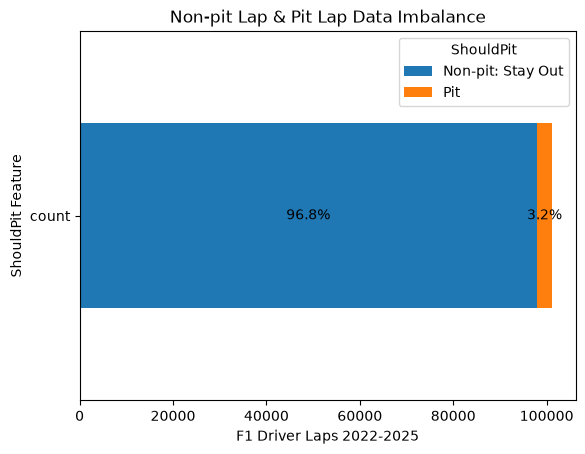

In [11]:
stacked_bar_visual(TRAINING_CSV)